In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, v_measure_score

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

# Load the preprocessed features for clustering
X_scaled = pd.read_csv('data/data_preprocessed.csv')

# Load the original data so we can use Gender as a reference label for v-measure
raw_df = pd.read_csv('data/Shopping Mall Customer Segmentation Data .csv')
reference_labels = raw_df['Gender']

print('Scaled data shape:', X_scaled.shape)
print('Reference labels shape:', reference_labels.shape)
print(X_scaled.head())

Scaled data shape: (15079, 4)
Reference labels shape: (15079,)
        Age  Gender  Annual_Income  Spending_Score
0 -0.666667     0.0       0.465394        0.775510
1  0.111111    -1.0       0.835265        0.897959
2  0.222222    -1.0      -0.421253        0.510204
3 -0.861111     0.0      -0.591304        0.122449
4 -0.833333     0.0       0.490409        0.510204


# K-Means Clustering Prototype

This notebook trains a K-Means clustering model on the preprocessed customer data.

`v_measure_score` is an external clustering validation metric. It checks how well the cluster assignments match a known reference label by combining:
- homogeneity: each cluster contains mostly one class
- completeness: each class is assigned mostly to one cluster

The score ranges from 0 to 1, where 1 means perfect agreement. For this project, it is best treated as a sanity-check metric, not the main clustering metric, because customer segmentation does not have true cluster labels.

K evaluation table:


,k,inertia,silhouette,v_measure_vs_gender
0,2,15260.079905,0.194807,0.000076
1,3,13017.848807,0.181685,0.000128
2,4,11111.910372,0.202347,0.000254
3,5,9911.853519,0.209124,0.235692
4,6,8956.067478,0.217194,0.356741
5,7,8092.815916,0.236119,0.437680
6,8,7361.659694,0.233796,0.365673
7,9,6633.213579,0.254039,0.427903
8,10,6092.601450,0.257027,0.415369


Best k based on silhouette score: 10

Final model metrics:
Inertia: 6092.60
Silhouette Score: 0.2570
V-measure vs Gender: 0.4154

Cluster counts:
Cluster
0    1480
1    1471
2    1332
3    1761
4    1743
5    1286
6    1345
7    1572
8    1396
9    1693
Name: count, dtype: int64


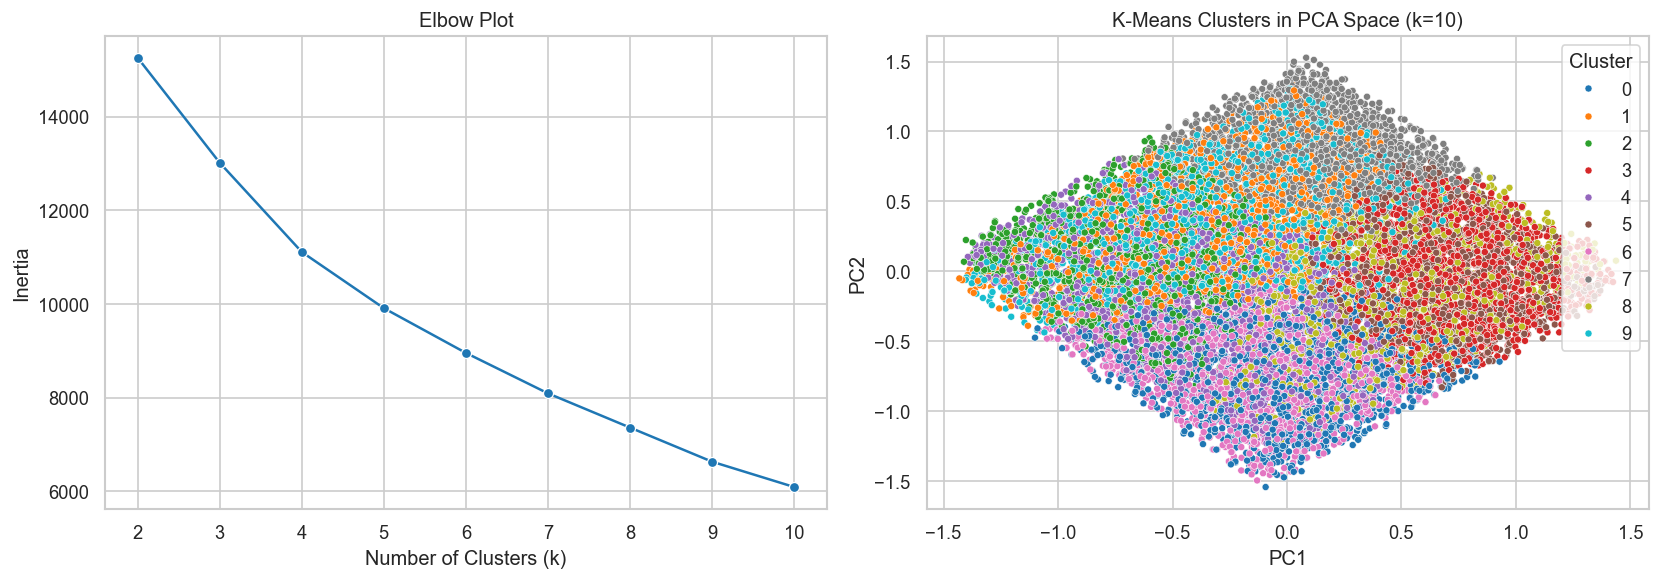

Saved clustered data to data/kmeans_clustered_data.csv


In [3]:
# Evaluate a range of k values first
score_rows = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = model.fit_predict(X_scaled)
    score_rows.append({
        'k': k,
        'inertia': model.inertia_,
        'silhouette': silhouette_score(X_scaled, cluster_labels),
        'v_measure_vs_gender': v_measure_score(reference_labels, cluster_labels)
    })

scores_df = pd.DataFrame(score_rows)
print('K evaluation table:')
display(scores_df)

best_k = scores_df.loc[scores_df['silhouette'].idxmax(), 'k']
print(f'Best k based on silhouette score: {best_k}')

# Train the final K-Means model
kmeans = KMeans(n_clusters=int(best_k), random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(X_scaled)

clustered_df = X_scaled.copy()
clustered_df['Cluster'] = cluster_labels

pca = PCA(n_components=2, random_state=42)
cluster_pca = pd.DataFrame(pca.fit_transform(X_scaled), columns=['PC1', 'PC2'])
cluster_pca['Cluster'] = cluster_labels

print()
print('Final model metrics:')
print(f"Inertia: {kmeans.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X_scaled, cluster_labels):.4f}")
print(f"V-measure vs Gender: {v_measure_score(reference_labels, cluster_labels):.4f}")
print()
print('Cluster counts:')
print(clustered_df['Cluster'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=scores_df, x='k', y='inertia', marker='o', ax=axes[0], color='#1f77b4')
axes[0].set_title('Elbow Plot')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

sns.scatterplot(data=cluster_pca, x='PC1', y='PC2', hue='Cluster', palette='tab10', s=18, ax=axes[1], legend='full')
axes[1].set_title(f'K-Means Clusters in PCA Space (k={int(best_k)})')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(title='Cluster', loc='best')

plt.tight_layout()
plt.show()

clustered_df.to_csv('data/kmeans_clustered_data.csv', index=False)
print('Saved clustered data to data/kmeans_clustered_data.csv')